<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/07_cLab_TcEstudiante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio — Determinación de la temperatura crítica del modelo de Ising 2D con redes neuronales de *scikit-learn*

**Maestría en Computación Científica · Módulo de Redes Neuronales · Modelo de Ising 2D**

En este laboratorio vas a **entrenar una red neuronal clasificadora con `scikit-learn`** y a
usarla como un *termómetro* para localizar la **temperatura crítica** $T_c$ de la transición
de fase ferromagnética del modelo de Ising en 2D.



## Objetivos de aprendizaje

Al terminar este laboratorio serás capaz de:

1. Entrenar un clasificador de red neuronal con `sklearn.neural_network.MLPClassifier`,
   identificando el papel de cada hiperparámetro.
2. **Contrastar la API de `scikit-learn`
3. Usar un clasificador entrenado **lejos** de la transición para estimar la fase
   (ordenada / desordenada) a temperaturas **cercanas** a $T_c$.
4. Estimar $T_c$ a partir del cruce $\langle P(y{=}1\mid X)\rangle = 0.5$, cuantificar su
   incertidumbre entre realizaciones y compararla con el valor exacto de Onsager.

## 1. Física: transición de fase del modelo de Ising 2D

El modelo de Ising 2D en una red $L\times L$ con acoplamiento ferromagnético $J>0$ tiene energía

$$E(\{s\}) = -J \sum_{\langle i,j\rangle} s_i\, s_j, \qquad s_i \in \{-1, +1\},$$

donde la suma es sobre pares de primeros vecinos. En unidades $J = k_B = 1$, el sistema infinito
presenta una transición de fase de segundo orden a la **temperatura crítica de Onsager**

$$T_c = \frac{2}{\ln\!\left(1+\sqrt{2}\right)} \approx 2.269.$$

- $T < T_c$: **fase ordenada** (ferromagnética), magnetización por sitio $|m|$ grande.
- $T > T_c$: **fase desordenada** (paramagnética), $|m|\approx 0$.

**Idea del laboratorio** (Carrasquilla & Melko, *Nature Physics* **13**, 431 (2017)): un
clasificador entrenado solo con configuraciones *claramente* ordenadas ($y=0$) y *claramente*
desordenadas ($y=1$) aprende una frontera de decisión que, evaluada en configuraciones cercanas
a $T_c$, se comporta como un **parámetro de orden efectivo**. La temperatura donde
$\langle P(y{=}1\mid X)\rangle = 0.5$ estima $T_c$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42
np.random.seed(RNG)

## 3. Datos: configuraciones lejos de $T_c$

`ising_dataset.npz` contiene configuraciones de espines de una red $16\times 16$ con frontera
periódica, generadas por Monte Carlo (Metrópolis). Campos:

| Campo | Forma | Significado |
|---|---|---|
| `X` | `(1600, 16, 16)` | Configuraciones de espines $s_i \in \{-1,+1\}$ |
| `y` | `(1600,)` | Etiqueta de fase: `0` = ordenada ($T$ baja), `1` = desordenada ($T$ alta) |
| `T` | `(1600,)` | Temperatura de cada configuración |
| `m` | `(1600,)` | Magnetización por sitio $|m|$ |
| `realizacion` | `(1600,)` | Índice de cadena Monte Carlo independiente (`0..3`) |
| `Tc`, `L`, `frontera` | escalares | Metadatos ($T_c$ exacto, tamaño, tipo de frontera) |

Las temperaturas de entrenamiento **evitan** la región crítica: hay un hueco entre
$T=1.9$ y $T=2.6$.

In [2]:
!unzip Datos.zip

Archive:  Datos.zip
   creating: Datos/
  inflating: Datos/ising_dataset.npz  
  inflating: Datos/temperatura_critica.npz  
  inflating: Datos/temperatura_critica20.npz  


In [3]:
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

Tc_exacto = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, "->", np.unique(y, return_counts=True))
print("realizaciones:", np.unique(realizacion))
print("Tc exacto (Onsager):", Tc_exacto)

X: (1600, 16, 16) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022


### Ejercicio 1 — Exploración

Responde con código y en una celda de texto:

1. ¿Qué temperaturas tienen etiqueta `y = 0` y cuáles `y = 1`? ¿Dónde está el "hueco"?
2. ¿Está balanceado el problema (cuántas configuraciones por clase)?
3. Grafica el histograma de $|m|$ separando por clase. ¿Se separan bien las dos fases?

Temperaturas con y = 0 (fase ordenada):
[1.2   1.375 1.55  1.725 1.9  ]

Temperaturas con y = 1 (fase desordenada):
[2.6   2.825 3.05  3.275 3.5  ]

Temperatura máxima de la clase y = 0: 1.9
Temperatura mínima de la clase y = 1: 2.6

Hueco sin datos de entrenamiento: 1.90 < T < 2.60

Número de configuraciones por clase:
y = 0: 800 configuraciones
y = 1: 800 configuraciones


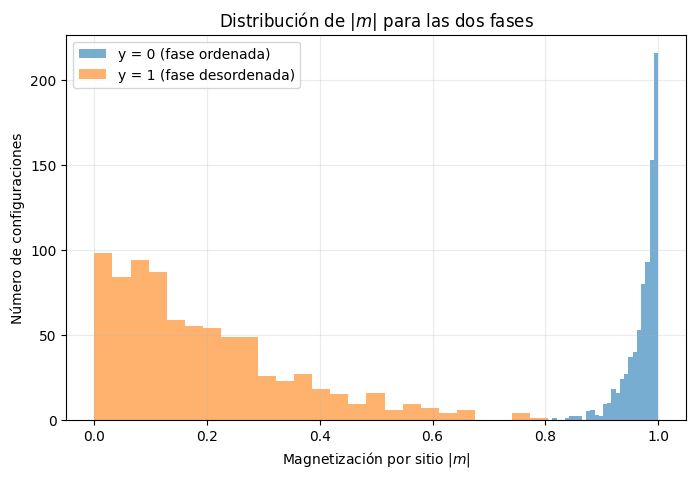

In [4]:
# --- Ejercicio 1  ---
# ============================================================
# Ejercicio 1 — Exploración de los datos
# ============================================================

# 1. Temperaturas correspondientes a cada clase
T_y0 = np.unique(T[y == 0])
T_y1 = np.unique(T[y == 1])

print("Temperaturas con y = 0 (fase ordenada):")
print(T_y0)

print("\nTemperaturas con y = 1 (fase desordenada):")
print(T_y1)

print("\nTemperatura máxima de la clase y = 0:", T_y0.max())
print("Temperatura mínima de la clase y = 1:", T_y1.min())

print(
    f"\nHueco sin datos de entrenamiento: "
    f"{T_y0.max():.2f} < T < {T_y1.min():.2f}"
)


# 2. Número de configuraciones por clase
clases, conteos = np.unique(y, return_counts=True)

print("\nNúmero de configuraciones por clase:")
for clase, cantidad in zip(clases, conteos):
    print(f"y = {clase}: {cantidad} configuraciones")


# 3. Histograma de |m| separado por clase
plt.figure(figsize=(8, 5))

plt.hist(
    m[y == 0],
    bins=25,
    alpha=0.6,
    label="y = 0 (fase ordenada)"
)

plt.hist(
    m[y == 1],
    bins=25,
    alpha=0.6,
    label="y = 1 (fase desordenada)"
)

plt.xlabel(r"Magnetización por sitio $|m|$")
plt.ylabel("Número de configuraciones")
plt.title(r"Distribución de $|m|$ para las dos fases")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


### Análisis del Ejercicio 1

**1. Temperaturas y hueco de entrenamiento**

Las configuraciones con etiqueta $y=0$ corresponden a temperaturas bajas,
es decir, a la fase ordenada o ferromagnética. Las configuraciones con
$y=1$ corresponden a temperaturas altas y representan la fase desordenada
o paramagnética.

A partir de los datos se observa que la temperatura máxima utilizada para
la clase ordenada es $T=1.9$, mientras que la temperatura mínima utilizada
para la clase desordenada es $T=2.6$. Por tanto, existe un hueco de
entrenamiento

$$
1.9 < T < 2.6.
$$

Este intervalo contiene la temperatura crítica exacta de Onsager,

$$
T_c \approx 2.269,
$$

por lo que el clasificador no será entrenado directamente con
configuraciones de la región crítica. Esto permitirá evaluar posteriormente
si la red neuronal puede identificar la transición a partir de las
configuraciones microscópicas de espines.

**2. Balance de las clases**

El conjunto contiene 1600 configuraciones en total:

- $800$ configuraciones con $y=0$.
- $800$ configuraciones con $y=1$.

Por tanto, el problema está balanceado, ya que cada clase representa el
$50\%$ del conjunto de datos.

**3. Magnetización**

El histograma de $|m|$ permite distinguir las dos fases. Las configuraciones
de la fase ordenada ($y=0$) presentan valores de $|m|$ relativamente altos,
como se espera cuando una gran fracción de los espines están alineados.

En cambio, las configuraciones de la fase desordenada ($y=1$) se concentran
en valores menores de $|m|$, debido a que las orientaciones de los espines
son más aleatorias y sus contribuciones a la magnetización tienden a
cancelarse.

Por tanto, la magnetización actúa como un buen parámetro de orden para
distinguir las dos fases en las regiones de temperatura utilizadas para el
entrenamiento.

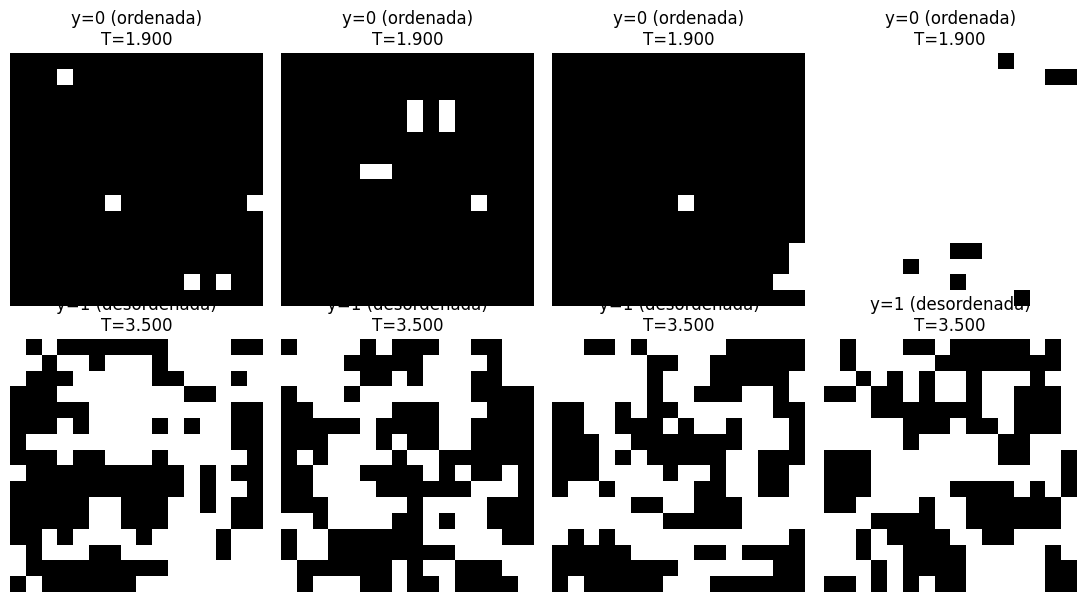

In [5]:
# Configuraciones típicas a T baja y T alta
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, (cls, titulo) in enumerate([(0, "ordenada"), (1, "desordenada")]):
    idx = np.where(y == cls)[0][:4]
    for k, i in enumerate(idx):
        axes[row, k].imshow(X[i], cmap="gray", vmin=-1, vmax=1)
        axes[row, k].set_title(f"y={cls} ({titulo})\nT={T[i]:.3f}")
        axes[row, k].axis("off")
plt.tight_layout()
plt.show()

### Interpretación de las configuraciones

Las configuraciones muestran de manera directa la diferencia entre las dos
fases del modelo de Ising. Para $T=1.9<T_c$, la red se encuentra fuertemente
ordenada: casi todos los espines presentan la misma orientación y solamente
aparecen pequeñas regiones con orientación contraria debido a las fluctuaciones
térmicas. Algunas configuraciones están dominadas por un estado de espín y
otras por el opuesto, lo cual es consistente con la simetría global
$s_i\rightarrow -s_i$ del modelo. En ambos casos, $|m|$ es cercano a uno.

Para $T=3.5>T_c$, las configuraciones presentan una mezcla mucho mayor de los
dos estados de espín y numerosos dominios distribuidos por toda la red. En
este régimen las contribuciones a la magnetización tienden a cancelarse, por
lo que $|m|$ toma valores cercanos a cero.

La comparación permite observar microscópicamente el paso de una fase
ferromagnética ordenada a una fase paramagnética desordenada al aumentar la
temperatura.

## 4. Partición de los datos: por **realización**

Las configuraciones de una misma cadena Monte Carlo (`realizacion`) están **correlacionadas**
temporalmente. Si mezcláramos al azar, configuraciones casi idénticas caerían en *train* y en
*test* a la vez → fuga de información y métricas infladas.

Partimos por realización:

- **Entrenamiento:** realizaciones `0` y `1`
- **Validación:** realización `2`
- **Prueba:** realización `3`

Además aplanamos cada configuración $16\times16 \to 256$ porque `MLPClassifier` espera
vectores de características.

### Ejercicio 2 — Construir los conjuntos

Completa las máscaras y los arreglos aplanados. Deberías obtener
`X_train (800, 256)`, `X_val (400, 256)` y `X_test (400, 256)`.

In [6]:
# --- Ejercicio 2  ---
mask_train = np.isin(realizacion, [0, 1])
mask_val   = realizacion == 2
mask_test  = realizacion == 3

def aplanar(A):
    return A.reshape(A.shape[0], L * L)

X_train, y_train, T_train = aplanar(X[mask_train]), y[mask_train], T[mask_train]
X_val,   y_val,   T_val   = aplanar(X[mask_val]),   y[mask_val],   T[mask_val]
X_test,  y_test,  T_test  = aplanar(X[mask_test]),  y[mask_test],  T[mask_test]

for nombre, Xs, ys in [("train", X_train, y_train),
                       ("val",   X_val,   y_val),
                       ("test",  X_test,  y_test)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

train  X=(800, 256)  y=(800,)  clases=[400 400]
val    X=(400, 256)  y=(400,)  clases=[200 200]
test   X=(400, 256)  y=(400,)  clases=[200 200]


### Análisis del Ejercicio 2

Los datos se dividieron utilizando el índice de realización de las cadenas
Monte Carlo. Las realizaciones 0 y 1 se utilizaron para entrenamiento, la
realización 2 para validación y la realización 3 para prueba. De esta forma
se evita mezclar configuraciones correlacionadas de una misma cadena entre
los diferentes conjuntos.

Cada configuración original tiene dimensión $16\times16$. Para utilizarla
como entrada de `MLPClassifier`, se aplanó en un vector de

$$
16\times16=256
$$

características.

Las dimensiones obtenidas fueron:

$$
X_{\mathrm{train}}:(800,256),
$$

$$
X_{\mathrm{val}}:(400,256),
$$

$$
X_{\mathrm{test}}:(400,256).
$$

Además, los tres conjuntos conservan el balance entre las dos clases. El
conjunto de entrenamiento contiene 400 configuraciones de cada fase, mientras
que validación y prueba contienen 200 configuraciones de cada fase.

Esta partición permite entrenar y evaluar el modelo utilizando realizaciones
Monte Carlo independientes, reduciendo el riesgo de fuga de información
debida a la correlación entre configuraciones de una misma cadena.

## 5. Entrenar el `MLPClassifier`

| Argumento | Valor | Qué controla |
|---|---|---|
| `hidden_layer_sizes=(16, 8, 4)` | 3 capas ocultas | Arquitectura: 256 → 16 → 8 → 4 → 2 |
| `activation="relu"` | ReLU | No linealidad de las capas ocultas |
| `solver="adam"` | Adam | Optimizador basado en gradiente estocástico |
| `learning_rate_init=0.001` | 0.001 | Tamaño de paso inicial |
| `max_iter=1000` | 1000 | Máximo de épocas (puede parar antes por tolerancia) |
| `random_state=42` | 42 | Reproducibilidad (init de pesos y *shuffling*) |

> La capa de salida (2 neuronas, *softmax*) y la pérdida (*log-loss*) las añade `scikit-learn`
> automáticamente al ver que `y` tiene dos clases enteras. En `NN_Cero.ipynb` esto era la
> `sigmoide` final + `cost_Function`; en PyTorch era `nn.Linear(..., 1)` + `BCEWithLogitsLoss`.

### Ejercicio 3 — Instanciar, entrenar y evaluar

1. Crea el modelo con los hiperparámetros de la tabla y ajústalo con `X_train, y_train`.
2. Reporta *accuracy* en train / val / test con `.score(...)`.
3. Grafica `model.loss_curve_` (la pérdida por época que `scikit-learn` guarda).

iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875


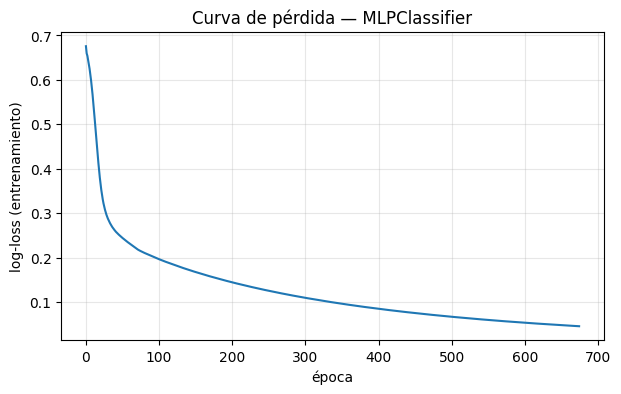

In [7]:
# --- Ejercicio 3  ---
model = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)
model.fit(X_train, y_train)

acc = {
    "train": model.score(X_train, y_train),
    "val":   model.score(X_val,   y_val),
    "test":  model.score(X_test,  y_test),
}
print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
for k, v in acc.items():
    print(f"accuracy {k:5s}: {v:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(model.loss_curve_)
plt.xlabel("época")
plt.ylabel("log-loss (entrenamiento)")
plt.title("Curva de pérdida — MLPClassifier")
plt.grid(alpha=0.3)
plt.show()

### Análisis del Ejercicio 3

El `MLPClassifier` convergió después de 675 iteraciones, antes de alcanzar el
máximo de 1000 establecido en `max_iter`. La pérdida final de entrenamiento
fue de $0.0453$.

Las exactitudes obtenidas fueron:

$$
\mathrm{accuracy}_{train}=1.0000,
$$

$$
\mathrm{accuracy}_{val}=0.9850,
$$

$$
\mathrm{accuracy}_{test}=0.9875.
$$

El modelo clasifica correctamente el $100\%$ de las configuraciones de
entrenamiento, el $98.5\%$ de las configuraciones de validación y el $98.75\%$
de las configuraciones de prueba. En términos del número de configuraciones,
esto corresponde a 394 de 400 clasificaciones correctas en validación y
395 de 400 en prueba.

Aunque el desempeño en entrenamiento es perfecto, las exactitudes de
validación y prueba permanecen muy cercanas. Por tanto, no se observa una
pérdida importante de capacidad de generalización al evaluar el modelo sobre
realizaciones Monte Carlo que no participaron en el entrenamiento.

La curva de pérdida presenta además un comportamiento estable. Inicialmente
la log-loss es cercana a $0.69$, valor compatible con un clasificador binario
que al comienzo del aprendizaje todavía no distingue adecuadamente las dos
clases. Durante las primeras iteraciones la pérdida disminuye rápidamente y
posteriormente continúa descendiendo de manera más gradual hasta alcanzar
$0.0453$.

Desde el punto de vista físico, estos resultados muestran que la red neuronal
es capaz de extraer de las configuraciones microscópicas de los 256 espines
información suficiente para distinguir con alta precisión la fase ordenada
($y=0$) de la fase desordenada ($y=1$) en las regiones de temperatura
utilizadas para el entrenamiento.

El siguiente paso será más exigente: evaluar si esta frontera de decisión,
aprendida con configuraciones alejadas de la transición, permite identificar
la región crítica y estimar $T_c$.

### Reflexión (sección 5)

- El *accuracy* de entrenamiento suele ser `1.0000`. ¿Es esto sobreajuste preocupante, dado que
  train / val / test dan valores parecidos? ¿Por qué este problema es "fácil" **lejos** de $T_c$?
- ¿Qué esperas que ocurra con las probabilidades del modelo **cerca** de $T_c$, donde no vio datos?

### Reflexión — Sección 5

El hecho de obtener un *accuracy* de entrenamiento igual a $1.0000$ no implica
por sí solo un sobreajuste preocupante. En este caso, las exactitudes de
validación y prueba fueron $0.9850$ y $0.9875$, respectivamente, valores muy
cercanos al resultado de entrenamiento. Además, estos conjuntos provienen de
realizaciones Monte Carlo diferentes de las utilizadas para entrenar el
modelo. Por tanto, la red mantiene un desempeño alto sobre configuraciones que
no participaron en el ajuste.

Este problema resulta relativamente fácil lejos de la temperatura crítica
porque las dos fases presentan características microscópicas claramente
diferentes. A temperaturas bajas, las configuraciones están fuertemente
ordenadas y la magnetización absoluta suele ser cercana a uno,

$$
|m|\approx 1,
$$

mientras que a temperaturas altas los espines presentan un mayor desorden y
la magnetización tiende hacia valores pequeños,

$$
|m|\approx 0.
$$

Esta separación también se observó en el histograma de magnetización y en las
configuraciones de espines visualizadas anteriormente. Por ello, la red puede
aprender con relativa facilidad una frontera entre ejemplos claramente
ordenados y claramente desordenados.

La situación debería ser diferente cerca de $T_c$. En esa región aparecen
fluctuaciones importantes y las configuraciones dejan de pertenecer de manera
tan evidente a una de las dos fases. Como la red tampoco fue entrenada con
datos del intervalo crítico, se espera encontrar probabilidades menos extremas
y una mayor variabilidad entre configuraciones.

En términos de la probabilidad de la fase desordenada, se espera que

$$
P(y=1\mid X)\approx 0
$$

a temperaturas suficientemente bajas y

$$
P(y=1\mid X)\approx 1
$$

a temperaturas suficientemente altas. Cerca de la transición deberían
aparecer valores intermedios. Al promediar sobre muchas configuraciones para
cada temperatura, se espera obtener una transición suave de
$\langle P(y=1\mid X)\rangle_T$ entre 0 y 1.

La hipótesis que se comprobará posteriormente es que la temperatura para la
cual

$$
\left\langle P(y=1\mid X)\right\rangle_T=0.5
$$

proporciona una estimación de la temperatura crítica del sistema.

## 6. El clasificador como termómetro

Para una configuración $X$, `model.predict_proba(X)[:, 1]` es $P(y{=}1\mid X)$: la "confianza"
del modelo en que la configuración pertenece a la **fase desordenada**.

Promediando sobre muchas configuraciones a temperatura fija $T$ obtenemos una curva
$\langle P(y{=}1\mid X)\rangle(T)$ que va de $\approx 0$ (ordenado) a $\approx 1$ (desordenado).
Definimos la estimación de $T_c$ como la temperatura del **cruce por 0.5**.

## 7. Datos de barrido fino alrededor de $T_c$

`temperatura_critica.npz` contiene **6200** configuraciones $16\times16$ en **31 temperaturas**
entre 1.6 y 3.2 (más densas cerca de $T_c$), con 4 realizaciones. **No trae etiquetas de
entrenamiento:** solo `y_ref`, una etiqueta obtenida aplicando el $T_c$ exacto, que usaremos
**únicamente para verificar** (usarla para entrenar sería hacer trampa).

In [8]:
datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)
X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L)
T_tc = datos_tc["T"]
realizacion_tc = datos_tc["realizacion"]
y_ref_tc = datos_tc["y_ref"]

print("X_tc:", X_tc.shape)
print("temperaturas:", np.unique(T_tc))

# Probabilidad de la clase "desordenada" (y = 1)
idx1 = list(model.classes_).index(1)
p1_tc = model.predict_proba(X_tc)[:, idx1]

# Chequeo con y_ref (NO usar para entrenar)
pred_tc = (p1_tc >= 0.5).astype(int)
print("accuracy vs y_ref (solo verificacion):",
      round((pred_tc == y_ref_tc).mean(), 4))

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8247


### Ejercicio 4 — Curva $\langle P\rangle$ vs $T$

Construye un `DataFrame` con columnas `T, realizacion, prob` y agrégalo por
`(realizacion, T)` para obtener la media y la desviación de `prob`. Grafica una curva por
realización y marca la línea $P = 0.5$.

   realizacion    T  prob_media  prob_std   N
0            0  1.6    0.086512  0.000394  50
1            0  1.7    0.099844  0.073550  50
2            0  1.8    0.118671  0.142166  50
3            0  1.9    0.096877  0.044426  50
4            0  2.0    0.194088  0.231677  50


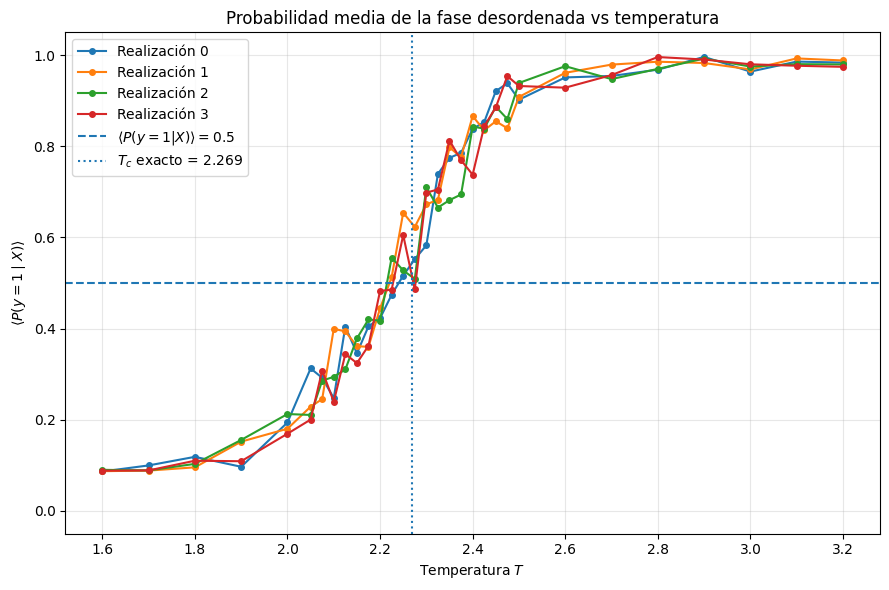

In [9]:
# --- Ejercicio 4 ---

# DataFrame con temperatura, realización y probabilidad de fase desordenada
df = pd.DataFrame({
    "T": T_tc,
    "realizacion": realizacion_tc,
    "prob": p1_tc
})

# Media, desviación estándar y número de configuraciones
# para cada temperatura y realización
resumen = (
    df.groupby(["realizacion", "T"])
      .agg(
          prob_media=("prob", "mean"),
          prob_std=("prob", "std"),
          N=("prob", "size")
      )
      .reset_index()
)

# Mostrar una parte del resumen
print(resumen.head())

# ------------------------------------------------------------
# Gráfico: <P(y=1|X)> en función de T para cada realización
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for r in sorted(resumen["realizacion"].unique()):
    datos_r = resumen[resumen["realizacion"] == r]

    plt.plot(
        datos_r["T"],
        datos_r["prob_media"],
        marker="o",
        markersize=4,
        label=f"Realización {r}"
    )

# Línea horizontal que define el cruce
plt.axhline(
    y=0.5,
    linestyle="--",
    label=r"$\langle P(y=1|X)\rangle = 0.5$"
)

# Valor exacto de Onsager como referencia
plt.axvline(
    x=Tc_exacto,
    linestyle=":",
    label=rf"$T_c$ exacto = {Tc_exacto:.3f}"
)

plt.xlabel(r"Temperatura $T$")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Probabilidad media de la fase desordenada vs temperatura")

plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Análisis del Ejercicio 4

La probabilidad media asignada por el clasificador a la fase desordenada
presenta una dependencia clara con la temperatura. Para temperaturas bajas,
las cuatro realizaciones muestran valores pequeños de

$$
\left\langle P(y=1\mid X)\right\rangle,
$$

lo cual indica que el modelo identifica mayoritariamente estas configuraciones
como pertenecientes a la fase ordenada.

Al aumentar la temperatura, la probabilidad media crece progresivamente y la
variación más pronunciada ocurre alrededor de la región crítica. Para
temperaturas altas, las cuatro curvas se aproximan a uno, indicando una alta
probabilidad asignada a la fase desordenada.

Las cuatro realizaciones presentan un comportamiento global semejante, aunque
se observan pequeñas fluctuaciones entre ellas, especialmente cerca de la
transición. Estas diferencias son razonables debido al carácter estadístico
de las configuraciones generadas mediante Monte Carlo y al tamaño finito del
sistema.

Un resultado especialmente importante es que las curvas cruzan el nivel

$$
\left\langle P(y=1\mid X)\right\rangle=0.5
$$

en una región cercana a la temperatura crítica exacta de Onsager,

$$
T_c^{\mathrm{exacto}}\approx 2.269.
$$

Esto es significativo porque el clasificador fue entrenado con configuraciones
alejadas de la región crítica y la temperatura no fue utilizada como
característica de entrada. La red aprendió a distinguir las fases a partir de
las configuraciones microscópicas de los espines, y su probabilidad de salida
se comporta como un indicador efectivo del cambio entre la fase ordenada y la
fase desordenada.

La gráfica permite localizar visualmente la región de transición, pero para
obtener una estimación cuantitativa de $T_c$ es necesario calcular el cruce
por $0.5$ para cada realización, por ejemplo mediante interpolación entre los
puntos vecinos al cruce.

### Ejercicio 5 — Estimar $T_c$ por interpolación

Para cada realización, encuentra el primer par de temperaturas consecutivas donde
$\langle P\rangle$ cruza 0.5 e interpola linealmente:

$$T_c \approx T_i + (0.5 - P_i)\,\frac{T_{i+1}-T_i}{P_{i+1}-P_i}.$$

Luego promedia entre realizaciones y reporta la media, la desviación estándar y el error
estándar de la media (SEM).

In [10]:
# --- Ejercicio 5  ---
def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

Tc_por_realizacion = []
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion.append(Tc_r)
    print(f"realización {r}:  Tc = {Tc_r:.4f}")

Tc_por_realizacion = np.array(Tc_por_realizacion)
Tc_est = np.nanmean(Tc_por_realizacion)
Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

print("\n" + "-" * 44)
print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f} (SEM)")
print(f"Tc Onsager     = {Tc_exacto:.4f}")
print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")

realización 0:  Tc = 2.2403
realización 1:  Tc = 2.2204
realización 2:  Tc = 2.2149
realización 3:  Tc = 2.2280

--------------------------------------------
Tc estimado    = 2.2259 +/- 0.0055 (SEM)
Tc Onsager     = 2.2692
error relativo = 1.91 %


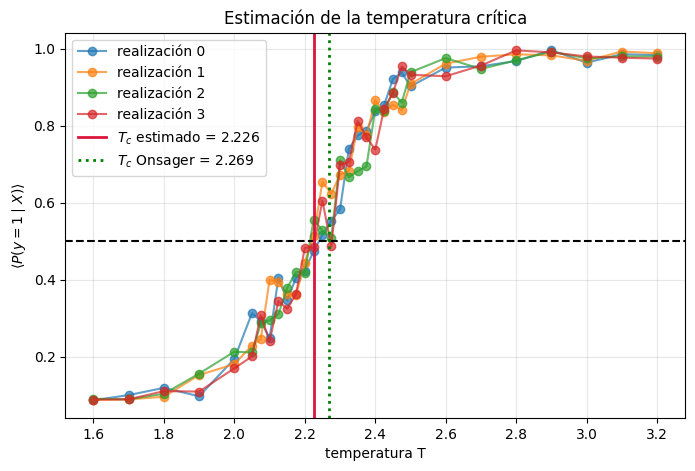

In [11]:
plt.figure(figsize=(8, 5))
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    plt.plot(d["T"], d["prob_media"], "o-", alpha=0.7, label=f"realización {r}")
plt.axhline(0.5, ls="--", color="k")
plt.axvline(Tc_est, ls="-", color="crimson", lw=2,
            label=fr"$T_c$ estimado = {Tc_est:.3f}")
plt.axvline(Tc_exacto, ls=":", color="green", lw=2,
            label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")
plt.xlabel("temperatura T")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Estimación de la temperatura crítica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Estimación de la temperatura crítica

La figura muestra la probabilidad media asignada por el clasificador a la
fase desordenada para cada una de las cuatro realizaciones Monte Carlo.

Para cada realización se determinó la temperatura en la que

$$
\left\langle P(y=1\mid X)\right\rangle = 0.5
$$

mediante interpolación lineal entre las dos temperaturas consecutivas que
rodean el primer cruce. Posteriormente, las cuatro estimaciones obtenidas se
promediaron para determinar la temperatura crítica estimada por el modelo.

La línea vertical asociada a $T_c$ estimado representa el valor medio obtenido
a partir de las realizaciones, mientras que la línea correspondiente a
$T_c$ de Onsager muestra el valor teórico exacto,

$$
T_c^{\mathrm{Onsager}} \approx 2.269.
$$

La proximidad entre ambas líneas permite evaluar directamente la capacidad
del clasificador para localizar la región crítica. Las diferencias entre los
cruces de las distintas realizaciones reflejan las fluctuaciones estadísticas
propias del muestreo Monte Carlo y permiten cuantificar la dispersión de la
estimación mediante la desviación estándar y el error estándar de la media
(SEM).

Este resultado es especialmente relevante porque la red fue entrenada
únicamente con configuraciones alejadas de la transición y no recibió la
temperatura como variable de entrada. Por tanto, la estimación de $T_c$ surge
del patrón aprendido a partir de las configuraciones microscópicas de los
espines.

## 8. Análisis crítico

Responde en celdas de texto, con evidencia (números o gráficas de tu notebook):

1. **Sesgo del estimador.** El $T_c$ estimado suele quedar *por debajo* de Onsager
   ($\approx 2.23$ vs $2.269$). Menciona al menos dos causas: tamaño finito $L=16$, definición
   de la etiqueta `y`, rango de temperaturas de entrenamiento, uso del umbral fijo 0.5.
2. **Arquitectura.** Repite el pipeline con `hidden_layer_sizes=(64,)` y con `(32, 16, 8)`.
   ¿Cambia $T_c$? ¿Cambia la *pendiente* de la curva en la transición?
3. **Reproducibilidad.** Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?
4. **Definición alternativa.** Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?
5. **Estandarización.** Los espines ya están en $\{-1,+1\}$. ¿Ayuda un `StandardScaler`?
   ¿Por qué sí o por qué no en este problema?

In [12]:
# --- Análisis crítico 1: sesgo del estimador ---

sesgo = Tc_est - Tc_exacto
error_abs = abs(sesgo)
error_rel = 100 * error_abs / Tc_exacto

print(f"Tc estimado : {Tc_est:.4f}")
print(f"Tc Onsager  : {Tc_exacto:.4f}")
print(f"Sesgo       : {sesgo:+.4f}")
print(f"Error abs.  : {error_abs:.4f}")
print(f"Error rel.  : {error_rel:.2f} %")

Tc estimado : 2.2259
Tc Onsager  : 2.2692
Sesgo       : -0.0433
Error abs.  : 0.0433
Error rel.  : 1.91 %


### 8.1. Sesgo del estimador

La temperatura crítica obtenida mediante el clasificador se encuentra
ligeramente desplazada respecto al valor exacto de Onsager. En particular,
el estimador presenta un desplazamiento hacia temperaturas menores.

Este resultado puede explicarse por varios factores.

En primer lugar, el sistema utilizado tiene un tamaño finito, $L=16$.
El valor

$$
T_c^{\mathrm{Onsager}}\approx2.269
$$

corresponde al límite termodinámico $L\rightarrow\infty$. En una red finita
la transición se encuentra redondeada y pueden aparecer desplazamientos de
la región de transición.

En segundo lugar, las etiquetas utilizadas para entrenar la red son binarias:
$y=0$ para configuraciones ordenadas y $y=1$ para configuraciones
desordenadas. Esta clasificación simplifica una transición que, para un
sistema finito, no aparece como un cambio perfectamente abrupto.

También influye el rango utilizado durante el entrenamiento. La red fue
entrenada únicamente con configuraciones alejadas de la región crítica,
dejando el intervalo $1.9<T<2.6$ fuera del entrenamiento. Por tanto, el
comportamiento del clasificador dentro de este intervalo surge de la
generalización de la frontera aprendida y no de ejemplos observados
directamente en esa región.

Finalmente, definir $T_c$ mediante el umbral fijo

$$
\langle P(y=1\mid X)\rangle=0.5
$$

es una elección operacional. No existe una razón termodinámica que obligue
a que el valor $0.5$ de la salida de una red neuronal coincida exactamente
con la temperatura crítica del sistema.

Por estas razones, una pequeña diferencia entre el $T_c$ estimado por la red
y el valor de Onsager es razonable y no implica necesariamente que el modelo
haya aprendido incorrectamente las dos fases.

In [13]:
# --- Análisis crítico 2: efecto de la arquitectura ---

arquitecturas = {
    "(16, 8, 4)": (16, 8, 4),
    "(64,)": (64,),
    "(32, 16, 8)": (32, 16, 8)
}

resultados_arq = []
curvas_arq = {}

for nombre, arquitectura in arquitecturas.items():

    # Crear y entrenar modelo
    modelo_arq = MLPClassifier(
        hidden_layer_sizes=arquitectura,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=RNG
    )

    modelo_arq.fit(X_train, y_train)

    # Probabilidad de y = 1
    idx1_arq = list(modelo_arq.classes_).index(1)
    prob = modelo_arq.predict_proba(X_tc)[:, idx1_arq]

    # DataFrame
    df_arq = pd.DataFrame({
        "T": T_tc,
        "realizacion": realizacion_tc,
        "prob": prob
    })

    resumen_arq = (
        df_arq.groupby(["realizacion", "T"])
              .agg(prob_media=("prob", "mean"))
              .reset_index()
    )

    # Tc para cada realización
    Tc_r_lista = []

    for r in np.unique(realizacion_tc):

        d = resumen_arq[
            resumen_arq["realizacion"] == r
        ].sort_values("T")

        Tc_r = cruce_05(
            d["T"].to_numpy(),
            d["prob_media"].to_numpy()
        )

        Tc_r_lista.append(Tc_r)

    Tc_r_lista = np.array(Tc_r_lista)

    Tc_media_arq = np.nanmean(Tc_r_lista)
    Tc_std_arq = np.nanstd(Tc_r_lista, ddof=1)

    # Accuracy
    acc_train = modelo_arq.score(X_train, y_train)
    acc_val = modelo_arq.score(X_val, y_val)
    acc_test = modelo_arq.score(X_test, y_test)

    resultados_arq.append({
        "arquitectura": nombre,
        "Tc_media": Tc_media_arq,
        "Tc_std": Tc_std_arq,
        "accuracy_train": acc_train,
        "accuracy_val": acc_val,
        "accuracy_test": acc_test
    })

    # Curva promedio entre realizaciones
    curva_media = (
        df_arq.groupby("T")["prob"]
              .mean()
              .reset_index()
    )

    curvas_arq[nombre] = curva_media


resultados_arq = pd.DataFrame(resultados_arq)

print(resultados_arq.round(4))

  arquitectura  Tc_media  Tc_std  accuracy_train  accuracy_val  accuracy_test
0   (16, 8, 4)    2.2259  0.0110             1.0         0.985         0.9875
1        (64,)    2.3736  0.0264             1.0         0.975         0.9675
2  (32, 16, 8)    2.3652  0.0131             1.0         0.980         0.9850


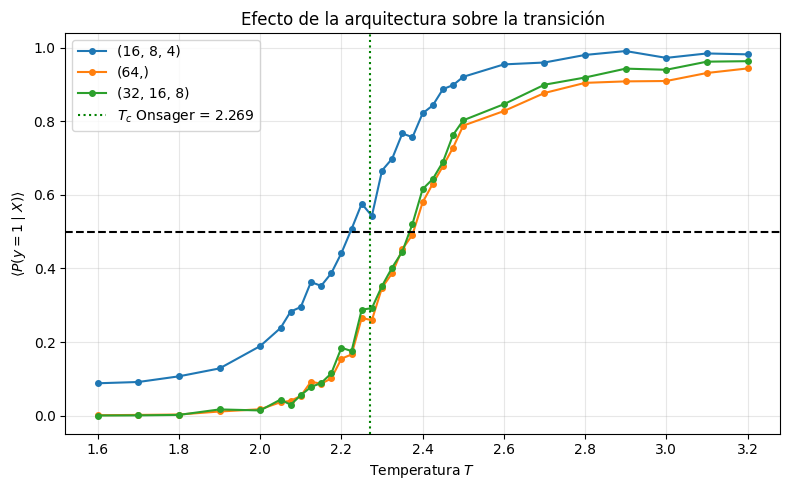

In [14]:
plt.figure(figsize=(8, 5))

for nombre, curva in curvas_arq.items():

    plt.plot(
        curva["T"],
        curva["prob"],
        "o-",
        markersize=4,
        label=nombre
    )

plt.axhline(0.5, linestyle="--", color="k")
plt.axvline(Tc_exacto, linestyle=":", color="green",
            label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")

plt.xlabel("Temperatura $T$")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Efecto de la arquitectura sobre la transición")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def pendiente_cruce(temps, probs):
    temps = np.asarray(temps)
    probs = np.asarray(probs)

    for i in range(len(temps) - 1):
        if ((probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0
                and probs[i + 1] != probs[i]):

            return (
                (probs[i + 1] - probs[i]) /
                (temps[i + 1] - temps[i])
            )

    return np.nan


print("\nPendiente aproximada alrededor del cruce:")

for nombre, curva in curvas_arq.items():

    pendiente = pendiente_cruce(
        curva["T"].to_numpy(),
        curva["prob"].to_numpy()
    )

    print(f"{nombre:12s}: {pendiente:.4f}")


Pendiente aproximada alrededor del cruce:
(16, 8, 4)  : 2.6159
(64,)       : 3.5125
(32, 16, 8) : 3.0062


### 8.2. Efecto de la arquitectura

Para estudiar la dependencia de la estimación de la temperatura crítica con
la arquitectura de la red, se repitió el mismo procedimiento utilizando tres
estructuras diferentes: `(16, 8, 4)`, `(64,)` y `(32, 16, 8)`. En todos los
casos se mantuvieron iguales los demás hiperparámetros y los conjuntos de
entrenamiento, validación y prueba.

Los resultados obtenidos fueron:

| Arquitectura | $T_c$ medio | STD | Accuracy test | Pendiente |
|---|---:|---:|---:|---:|
| `(16, 8, 4)` | 2.2259 | 0.0110 | 0.9875 | 2.6159 |
| `(64,)` | 2.3736 | 0.0264 | 0.9675 | 3.5125 |
| `(32, 16, 8)` | 2.3652 | 0.0131 | 0.9850 | 3.0062 |

Tomando como referencia el valor exacto de Onsager,

$$
T_c^{\mathrm{Onsager}}\approx 2.2692,
$$

se observa que la arquitectura sí modifica de manera apreciable la
temperatura crítica estimada. La arquitectura original `(16, 8, 4)` produce

$$
T_c=2.2259,
$$

por debajo del valor de Onsager, mientras que `(64,)` y `(32, 16, 8)`
producen respectivamente

$$
T_c=2.3736
$$

y

$$
T_c=2.3652,
$$

ambos por encima del valor teórico.

También cambia la pendiente de la curva alrededor de la transición. La
pendiente local se estimó mediante

$$
S \approx
\frac{P_{i+1}-P_i}{T_{i+1}-T_i},
$$

utilizando los puntos que rodean el cruce por $P=0.5$. Se obtuvieron valores
de 2.6159, 3.5125 y 3.0062 para `(16, 8, 4)`, `(64,)` y `(32, 16, 8)`,
respectivamente. Por lo tanto, la arquitectura `(64,)` presenta el cambio
local más abrupto alrededor de su transición, mientras que `(16, 8, 4)`
presenta el menos pronunciado de los tres.

Un resultado importante es que un desempeño de clasificación similar lejos
de la transición no implica necesariamente la misma estimación de $T_c$.
Por ejemplo, `(16, 8, 4)` y `(32, 16, 8)` alcanzaron accuracies de prueba de
0.9875 y 0.9850, respectivamente, pero sus temperaturas críticas estimadas
fueron 2.2259 y 2.3652.

Esto indica que la arquitectura afecta la frontera probabilística aprendida
por el clasificador en la región crítica, que fue excluida del entrenamiento.
En consecuencia, tanto la posición del cruce por 0.5 como la pendiente de la
curva deben considerarse propiedades del clasificador utilizado y no
únicamente propiedades termodinámicas del sistema.

In [16]:
# --- Análisis crítico 3: reproducibilidad ---

semillas = [0, 1, 2, 3, 4]

resultados_semillas = []

for seed in semillas:

    modelo_seed = MLPClassifier(
        hidden_layer_sizes=(16, 8, 4),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=seed
    )

    modelo_seed.fit(X_train, y_train)

    idx1_seed = list(modelo_seed.classes_).index(1)
    prob_seed = modelo_seed.predict_proba(X_tc)[:, idx1_seed]

    df_seed = pd.DataFrame({
        "T": T_tc,
        "realizacion": realizacion_tc,
        "prob": prob_seed
    })

    resumen_seed = (
        df_seed.groupby(["realizacion", "T"])
               .agg(prob_media=("prob", "mean"))
               .reset_index()
    )

    Tc_seed_realizaciones = []

    for r in np.unique(realizacion_tc):

        d = resumen_seed[
            resumen_seed["realizacion"] == r
        ].sort_values("T")

        Tc_r = cruce_05(
            d["T"].to_numpy(),
            d["prob_media"].to_numpy()
        )

        Tc_seed_realizaciones.append(Tc_r)

    Tc_seed = np.nanmean(Tc_seed_realizaciones)

    resultados_semillas.append(Tc_seed)

    print(f"semilla {seed}: Tc = {Tc_seed:.4f}")


resultados_semillas = np.array(resultados_semillas)

Tc_seed_media = np.mean(resultados_semillas)
Tc_seed_std = np.std(resultados_semillas, ddof=1)

print("\n" + "-" * 45)
print(f"Tc medio entre semillas = {Tc_seed_media:.4f}")
print(f"desviación por semilla  = {Tc_seed_std:.4f}")
print(f"desviación realizaciones = {Tc_std:.4f}")

if Tc_seed_std < Tc_std:
    print("La dispersión por semilla es MENOR que entre realizaciones.")
elif Tc_seed_std > Tc_std:
    print("La dispersión por semilla es MAYOR que entre realizaciones.")
else:
    print("Las dos dispersiones son aproximadamente iguales.")

semilla 0: Tc = 2.3578
semilla 1: Tc = 2.3633
semilla 2: Tc = 2.3619
semilla 3: Tc = 2.2767
semilla 4: Tc = 2.3583

---------------------------------------------
Tc medio entre semillas = 2.3436
desviación por semilla  = 0.0375
desviación realizaciones = 0.0110
La dispersión por semilla es MAYOR que entre realizaciones.


### 8.3. Reproducibilidad frente a la semilla aleatoria

Para evaluar la reproducibilidad del procedimiento se mantuvo fija la
arquitectura original `(16, 8, 4)` y se repitió el entrenamiento utilizando
cinco valores diferentes de `random_state`.

Los resultados obtenidos fueron:

| Semilla | $T_c$ estimado |
|---:|---:|
| 0 | 2.3578 |
| 1 | 2.3633 |
| 2 | 2.3619 |
| 3 | 2.2767 |
| 4 | 2.3583 |

El promedio y la desviación estándar entre semillas fueron

$$
\boxed{T_c = 2.3436 \pm 0.0375}
$$

donde la incertidumbre reportada corresponde a la desviación estándar de las
cinco estimaciones.

La dispersión debida a la semilla fue

$$
\sigma_{\mathrm{semillas}}=0.0375,
$$

mientras que la dispersión entre las realizaciones Monte Carlo obtenida para
el modelo original fue

$$
\sigma_{\mathrm{realizaciones}}=0.0110.
$$

Por tanto,

$$
\sigma_{\mathrm{semillas}} >
\sigma_{\mathrm{realizaciones}},
$$

y en este experimento la dispersión asociada al entrenamiento de la red es
aproximadamente 3.4 veces mayor que la dispersión observada entre las
realizaciones Monte Carlo.

Este resultado muestra que la estimación de $T_c$ presenta una sensibilidad
apreciable a la inicialización aleatoria del MLP. Aunque se mantienen la misma
arquitectura y los mismos datos, diferentes semillas pueden conducir a
diferentes parámetros finales de la red y, en consecuencia, a diferentes
fronteras probabilísticas dentro de la región crítica.

Es especialmente visible en la semilla 3, para la cual se obtuvo
$T_c=2.2767$, mientras que las otras cuatro semillas produjeron valores
cercanos a $2.36$. No sería adecuado seleccionar una semilla particular por
su cercanía al valor exacto de Onsager; para evaluar la reproducibilidad es
necesario considerar el conjunto completo de ejecuciones.

En consecuencia, los resultados indican que la incertidumbre del
``termómetro'' neuronal no proviene únicamente de las fluctuaciones entre
realizaciones Monte Carlo. La aleatoriedad propia del entrenamiento de la red
también constituye una fuente importante de variabilidad.

In [17]:
# --- Análisis crítico 4: definición alternativa ---

pred_tc_alt = (p1_tc >= 0.5).astype(int)

df_alt = pd.DataFrame({
    "T": T_tc,
    "realizacion": realizacion_tc,
    "pred": pred_tc_alt
})

resumen_alt = (
    df_alt.groupby(["realizacion", "T"])
          .agg(fraccion_fase1=("pred", "mean"))
          .reset_index()
)

Tc_alt_realizaciones = []

for r in np.unique(realizacion_tc):

    d = resumen_alt[
        resumen_alt["realizacion"] == r
    ].sort_values("T")

    Tc_r = cruce_05(
        d["T"].to_numpy(),
        d["fraccion_fase1"].to_numpy()
    )

    Tc_alt_realizaciones.append(Tc_r)

Tc_alt_realizaciones = np.array(Tc_alt_realizaciones)

Tc_alt = np.nanmean(Tc_alt_realizaciones)
Tc_alt_std = np.nanstd(Tc_alt_realizaciones, ddof=1)

print("Método probabilidad media:")
print(f"Tc = {Tc_est:.4f}")

print("\nMétodo fracción clasificada como fase 1:")
print(f"Tc = {Tc_alt:.4f} +/- {Tc_alt_std:.4f} (STD)")

print(f"\nDiferencia = {Tc_alt - Tc_est:+.4f}")

Método probabilidad media:
Tc = 2.2259

Método fracción clasificada como fase 1:
Tc = 2.2331 +/- 0.0134 (STD)

Diferencia = +0.0072


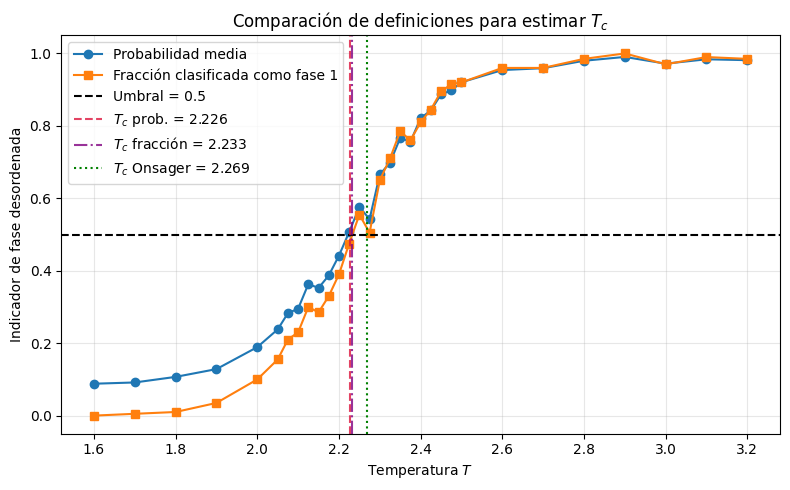

In [23]:
# Curvas promedio para las dos definiciones

curva_prob = (
    df.groupby("T")["prob"]
      .mean()
      .reset_index()
)

curva_alt = (
    df_alt.groupby("T")["pred"]
          .mean()
          .reset_index()
)

plt.figure(figsize=(8, 5))

# Probabilidad media
plt.plot(
    curva_prob["T"],
    curva_prob["prob"],
    "o-",
    label="Probabilidad media"
)

# Fracción clasificada como fase 1
plt.plot(
    curva_alt["T"],
    curva_alt["pred"],
    "s-",
    label="Fracción clasificada como fase 1"
)

# Nivel del cruce
plt.axhline(
    0.5,
    linestyle="--",
    color="k",
    label="Umbral = 0.5"
)

# Tc obtenido con probabilidad media
plt.axvline(
    Tc_est,
    linestyle="--",
    color="crimson",
    alpha=0.8,
    label=fr"$T_c$ prob. = {Tc_est:.3f}"
)

# Tc obtenido con fracción de fase 1
plt.axvline(
    Tc_alt,
    linestyle="-.",
    color="purple",
    alpha=0.8,
    label=fr"$T_c$ fracción = {Tc_alt:.3f}"
)

# Valor exacto
plt.axvline(
    Tc_exacto,
    linestyle=":",
    color="green",
    label=fr"$T_c$ Onsager = {Tc_exacto:.3f}"
)

plt.xlabel("Temperatura $T$")
plt.ylabel("Indicador de fase desordenada")
plt.title("Comparación de definiciones para estimar $T_c$")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 8.4. Definición alternativa del estimador

Para comprobar si la estimación de la temperatura crítica depende de la forma
en que se utiliza la salida del clasificador, se compararon dos definiciones.

En el primer método se utilizó directamente la probabilidad media de pertenecer
a la fase desordenada,

$$
\left\langle P(y=1\mid X)\right\rangle,
$$

mientras que en el segundo cada configuración se clasificó primero mediante

$$
\hat y =
\begin{cases}
0, & P(y=1\mid X)<0.5,\\
1, & P(y=1\mid X)\geq0.5,
\end{cases}
$$

y posteriormente se calculó la fracción de configuraciones clasificadas como
fase 1 para cada temperatura.

Los resultados fueron

$$
T_c^{(\mathrm{probabilidad})}=2.2259
$$

y

$$
T_c^{(\mathrm{fracción})}=2.2331\pm0.0134,
$$

donde la incertidumbre del segundo valor corresponde a la desviación estándar
entre realizaciones.

La diferencia entre ambas estimaciones es

$$
\Delta T_c
=
T_c^{(\mathrm{fracción})}
-
T_c^{(\mathrm{probabilidad})}
=
0.0072,
$$

lo que corresponde aproximadamente a un $0.32\%$ respecto al primer
estimador.

Por tanto, aunque las dos definiciones no son matemáticamente equivalentes,
en este conjunto de datos producen estimaciones muy cercanas de la temperatura
crítica.

La gráfica permite observar que las mayores diferencias entre ambos indicadores
aparecen lejos de la transición. La probabilidad media conserva información
sobre el grado de confianza del clasificador, mientras que la fracción
clasificada convierte cada configuración en una decisión binaria y pierde
esa información. Por ejemplo, probabilidades de 0.1 y 0.4 contribuyen de
manera diferente a la probabilidad media, pero ambas se convierten en
$\hat y=0$ al utilizar el umbral de 0.5.

A pesar de esta diferencia, las dos curvas atraviesan el nivel 0.5 en una
región muy similar. Además, ambas estimaciones permanecen por debajo del valor
exacto de Onsager,

$$
T_c^{\mathrm{Onsager}}\approx2.2692.
$$

Esto indica que, para el modelo original, la estimación de $T_c$ es
relativamente robusta frente a estas dos definiciones del indicador de fase,
aunque la forma completa de las curvas no sea idéntica.

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
# --- Análisis crítico 5: StandardScaler ---

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_val_std   = scaler.transform(X_val)
X_test_std  = scaler.transform(X_test)
X_tc_std    = scaler.transform(X_tc)

model_std = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG
)

model_std.fit(X_train_std, y_train)

print("Sin StandardScaler:")
print(f"train = {acc['train']:.4f}")
print(f"val   = {acc['val']:.4f}")
print(f"test  = {acc['test']:.4f}")

print("\nCon StandardScaler:")
print(f"train = {model_std.score(X_train_std, y_train):.4f}")
print(f"val   = {model_std.score(X_val_std, y_val):.4f}")
print(f"test  = {model_std.score(X_test_std, y_test):.4f}")

Sin StandardScaler:
train = 1.0000
val   = 0.9850
test  = 0.9875

Con StandardScaler:
train = 1.0000
val   = 0.9875
test  = 0.9900


In [21]:
idx1_std = list(model_std.classes_).index(1)

p1_std = model_std.predict_proba(X_tc_std)[:, idx1_std]

df_std = pd.DataFrame({
    "T": T_tc,
    "realizacion": realizacion_tc,
    "prob": p1_std
})

resumen_std = (
    df_std.groupby(["realizacion", "T"])
          .agg(prob_media=("prob", "mean"))
          .reset_index()
)

Tc_std_scaler = []

for r in np.unique(realizacion_tc):

    d = resumen_std[
        resumen_std["realizacion"] == r
    ].sort_values("T")

    Tc_r = cruce_05(
        d["T"].to_numpy(),
        d["prob_media"].to_numpy()
    )

    Tc_std_scaler.append(Tc_r)

Tc_scaler_media = np.nanmean(Tc_std_scaler)

print(f"\nTc sin escalar = {Tc_est:.4f}")
print(f"Tc escalado    = {Tc_scaler_media:.4f}")
print(f"diferencia     = {Tc_scaler_media - Tc_est:+.4f}")


Tc sin escalar = 2.2259
Tc escalado    = 2.2076
diferencia     = -0.0183


### 8.5. Efecto de la estandarización

En este problema las características de entrada corresponden directamente a
los espines,

$$
s_i\in\{-1,+1\}.
$$

Por tanto, todas las características están originalmente en la misma escala y
sus valores se encuentran acotados. Esto es diferente de otros problemas de
aprendizaje automático en los que las variables pueden presentar escalas muy
distintas y la estandarización resulta esencial para facilitar la
optimización.

`StandardScaler` transforma cada característica utilizando la media y la
desviación estándar calculadas exclusivamente sobre el conjunto de
entrenamiento. Aunque esta transformación puede modificar ligeramente la
optimización de la red, en este problema no se espera una mejora drástica,
porque los espines ya presentan una escala homogénea.

La conclusión debe comprobarse comparando el *accuracy* y la estimación de
$T_c$ obtenidos con y sin estandarización. Si ambos resultados permanecen
cercanos, esto indicará que la representación original $s_i\in\{-1,+1\}$ ya
es adecuada para el entrenamiento del MLP.

### 8.5. Efecto de la estandarización

Para estudiar el efecto de la estandarización se aplicó `StandardScaler`,
ajustándolo exclusivamente con el conjunto de entrenamiento y utilizando
posteriormente la misma transformación sobre los conjuntos de validación,
prueba y barrido de temperatura.

Los resultados de clasificación fueron:

| Conjunto | Sin StandardScaler | Con StandardScaler |
|---|---:|---:|
| Entrenamiento | 1.0000 | 1.0000 |
| Validación | 0.9850 | 0.9875 |
| Prueba | 0.9875 | 0.9900 |

La estandarización produjo, por tanto, una mejora pequeña de 0.0025 en
*accuracy* tanto en validación como en prueba. Sin embargo, esta diferencia
es reducida y no representa un cambio importante en la capacidad de
clasificación.

Este comportamiento es razonable porque las características originales
corresponden directamente a los espines,

$$
s_i\in\{-1,+1\},
$$

por lo que todas las variables ya se encuentran acotadas y en la misma
escala. A diferencia de otros problemas en los que las características
presentan órdenes de magnitud muy diferentes, aquí no existe un problema
importante de escalas que `StandardScaler` deba corregir.

También se evaluó el efecto de la estandarización sobre la estimación de la
temperatura crítica. Se obtuvo

$$
T_c^{(\mathrm{sin\ escalar})}=2.2259
$$

y

$$
T_c^{(\mathrm{escalado})}=2.2076,
$$

por lo que

$$
\Delta T_c
=
T_c^{(\mathrm{escalado})}
-
T_c^{(\mathrm{sin\ escalar})}
=
-0.0183.
$$

Tomando como referencia el valor exacto de Onsager,

$$
T_c^{(\mathrm{Onsager})}\approx2.2692,
$$

la estandarización no acercó la estimación al valor teórico en esta
ejecución. Aunque el *accuracy* de prueba aumentó ligeramente de 0.9875 a
0.9900, la estimación de $T_c$ se desplazó hacia una temperatura menor.

Por tanto, en este problema `StandardScaler` no resulta esencial. Los espines
ya poseen una representación homogénea en $\{-1,+1\}$ y la estandarización
solo produce cambios pequeños en las métricas de clasificación. Además, los
resultados muestran que una pequeña mejora en *accuracy* no implica
necesariamente una mejor estimación de la temperatura crítica.

## 9. Reto  — Escalamiento con el tamaño del sistema

Con el programa de ising generar varias datos para diferentes tipo de redes L=10x10, L=15x15, L=20x20, L=25x25, L=30x30

1. Construye un conjunto de entrenamiento.
2. Entrena un nuevo `MLPClassifier`, repite los Ejercicios 4–5 y obtén $T_c(L=20)$.
3. Compara todas las $T_c$ ¿La estimación se acerca a Onsager al crecer $L$?
   Relaciónalo con el *finite-size scaling*.